# Homework 2: Generative Models for Inverse Problems

This homework is based on the material of the **generative-model** chapter, with emphasis on the use of learned priors for inverse problems. The goal is to reuse pretrained generative models from the lecture notebooks and study how they can guide reconstruction under a known forward operator, following the broad perspective of learned priors surveyed .

Starting from clean Mayo images $\{\boldsymbol{x}_i\}_{i=1}^N$, you will generate synthetic measurements of the form

$$
    \boldsymbol{y}_i^\delta = K\boldsymbol{x}_i + \boldsymbol{e},
$$

where $K$ is a known motion-blur operator and $\boldsymbol{e}$ is additive Gaussian noise. You will then compare at least two reconstruction strategies:

- a **generator-range prior** method based on a pretrained **VAE decoder** ;
- a **diffusion-prior** method based on the pretrained denoiser from the diffusion notebook.

The purpose of the assignment is not to reproduce a research paper line by line, but to demonstrate that you understand the algorithmic logic of generative priors: latent-space optimization, data fidelity, denoising guidance, and the tradeoff between realism and measurement consistency.


## Homework Goals and Deliverables

You are asked to complete the notebook and submit the following:

1. A completed version of this notebook with all `TODO` sections filled in.
2. The pretrained weights you reused from the lecture notebooks, together with any additional saved results you produced for this homework.
3. A short written discussion, included at the end of the notebook, answering the conceptual questions.
4. At least one figure comparing the corrupted datum and the final reconstructions produced by your methods on the same test image.

Your work should show that you can:

- build a dataset pipeline consistent with the generative models used in the lectures;
- simulate an inverse problem through a known operator $K$;
- load and reuse pretrained generative models correctly;
- implement a latent-prior reconstruction procedure;
- implement a diffusion-prior reconstruction procedure;
- compare the methods critically rather than only visually.


Use grayscale images resized to $64 \times 64$, because this is the resolution used by the VAE, GAN, and diffusion lecture notebooks.



Do **not** use external pretrained foundation models, external inverse-problem toolkits, or black-box diffusion pipelines. This includes downloading a ready-made Hugging Face diffusion pipeline instead of reusing the course denoiser. The homework is about reusing and understanding the models developed in this course.



## Suggested Structure of the Work

A reasonable workflow is to start from the data and corruption model, then load the pretrained generative models, then implement the reconstruction procedures, and finally compare them on the same examples.

The **mandatory** part of the homework is:

- one **VAE-based latent prior** reconstruction;
- one **diffusion-prior** reconstruction, choosing either a DPS-style or a DiffPIR-style method.

An optional extension is to include a **GAN-based generator prior** or to implement **both** DPS-style and DiffPIR-style diffusion reconstructions and discuss how the comparison changes.

The notebook intentionally leaves several implementation choices open. You are expected to reuse the ideas developed in the lecture notebooks, but not simply copy them without understanding the role of each step.


In [12]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm

book_root = Path('.').resolve()

sys.path.append('.')
from IPPy import operators, utilities
import operators
from utilities import gaussian_noise, get_device


from IPPy.nn.diffusion import DiffusionUNet, cosine_beta_schedule, denormalize_to_01, extract

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

device = get_device()
torch.manual_seed(0)

print('Working device:', device)
print('Weights directory:', weights_dir)


Working device: mps
Weights directory: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights


## Part 1: Data Pipeline, Corruption Model, and Pretrained Models

In this first part, build a dataset for the Mayo images at $64 \times 64$, define the synthetic inverse problem, and load the pretrained generative models from the lecture notebooks.

The objective of this part is to verify that the data pipeline, the corruption model, and the reused weights are all correct **before** the reconstruction procedures are implemented.

Be careful about **architecture compatibility**. The diffusion weights now correspond to the stronger lecture denoiser used in the diffusion notebook, so your `DiffusionUNet` definition must match that notebook exactly when you call `load_state_dict`. In particular, reuse the same configuration (`in_ch=1`, `base_ch=64`, `channel_mults=(1, 2, 4)`, `time_dim=256`, attention enabled at the same levels, and the same diffusion schedule).

You should at least load:

- the pretrained **VAE** from `../weights/VAE.pth`;
- the pretrained **diffusion denoiser** from `../weights/DDPMDenoiser.pth`.

If you attempt the optional extension, you may also load the pretrained **GAN** generator from `../weights/GAN_G_EMA.pth`.


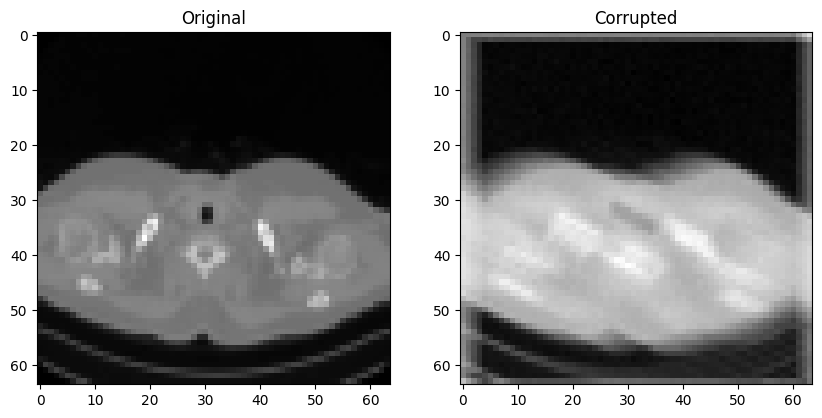

In [13]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        img = Image.open(img_path).convert('L')
        return self.transform(img)

# 1. Build the training and test datasets and create the dataloaders.

train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=64)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

example_image = train_dataset[0]

# 2. Define the forward operator K and the additive noise level.
K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

# 3. Visualize at least one clean / corrupted pair.
# How much noise how want to add
noise_level = 0.01

# 2. take one image x from the training loader
# 3. compute y_delta = K(x) + gaussian_noise(...)
with torch.no_grad():
    # Doesn't save the gradient (we don't need now and it's a heavy op)
    y = K(example_image)
    y_delta = y + gaussian_noise(y, noise_level)
# 4. visualize x and y_delta
# 4. visualizza x e y_delta
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(example_image.squeeze(), cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(y_delta.squeeze(), cmap='gray')
axes[1].set_title('Corrupted')
plt.show()

# 4. Recreate the pretrained model classes from the lecture notebooks
#    and load the VAE and diffusion weights from ../weights/.
#    For the diffusion model, match the lecture architecture exactly
#    and keep the image normalization in [-1, 1].


# VAE

In [14]:


def norm_layer(channels):
    num_groups = 8 if channels >= 8 else 1
    return nn.GroupNorm(num_groups=num_groups, num_channels=channels)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            norm_layer(32),
            nn.SiLU(),
            ResidualBlock(32),
        )
        self.down1 = DownBlock(32, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)

        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)

        self.up1 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up3 = UpsampleBlock(128, 64)
        self.up4 = UpsampleBlock(64, 32)
        self.out_conv = nn.Sequential(
            norm_layer(32),
            nn.SiLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.stem(x)
        h = self.down1(h)
        h = self.down2(h)
        h = self.down3(h)
        h = self.down4(h)
        h = h.flatten(start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(min=-4.5, max=1.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(z.shape[0], 512, 4, 4)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        h = self.up4(h)
        return self.out_conv(h)

    def reconstruct_deterministic(self, x):
        mu, _ = self.encode(x)
        return self.decode(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


# Define x_true and ensure batched shape for later use
x_true = example_image.unsqueeze(0).to(device)
y_delta = y_delta.unsqueeze(0).to(device)

# Load VAE weights
vae = ConvVAE(latent_dim=64).to(device)
vae.load_state_dict(torch.load(weights_dir / 'VAE.pth', map_location=device))
vae.eval()

ConvVAE(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): SiLU()
    (3): ResidualBlock(
      (block): Sequential(
        (0): GroupNorm(8, 32, eps=1e-05, affine=True)
        (1): SiLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm(8, 32, eps=1e-05, affine=True)
        (4): SiLU()
        (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): SiLU()
      (3): ResidualBlock(
        (block): Sequential(
          (0): GroupNorm(8, 64, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): GroupNorm(8, 64, eps=1e-05, aff

## Part 2: Latent Reconstruction with a Generator Prior

Use the pretrained **VAE decoder** as a generator prior. The idea is to reconstruct an image by optimizing a latent code $\boldsymbol{z}$ so that the generated image both matches the measurements and remains plausible under the latent prior, in the spirit of deep generative priors for inverse problems {cite}`kingma2014auto,bora2017compressed`.

A standard objective has the form

$$
    \min_{\boldsymbol{z}} \; \|K G(\boldsymbol{z}) - \boldsymbol{y}^\delta\|_2^2 + \lambda \|\boldsymbol{z}\|_2^2,
$$

where $G$ denotes the decoder and $\lambda$ controls the latent regularization.

The mandatory part is to implement the **VAE-based** version. If you want the optional extension, you may implement the same idea with the GAN generator and compare the behavior.


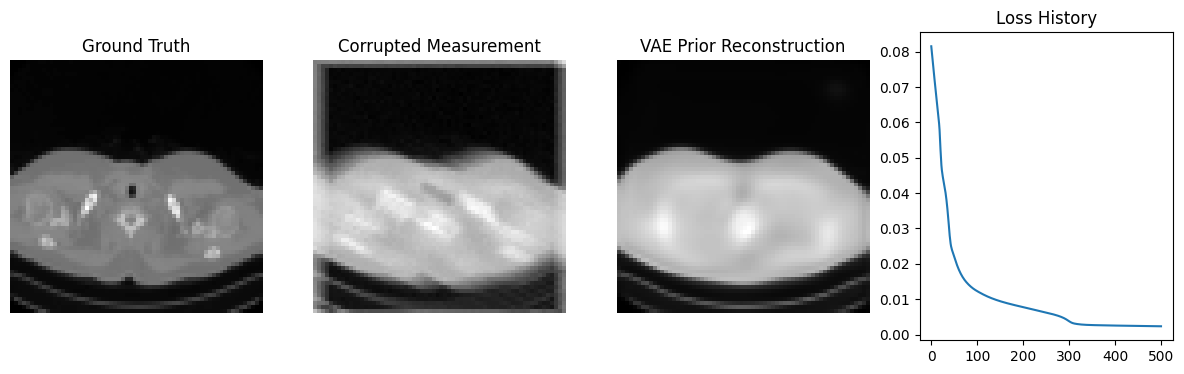

In [15]:
def latent_objective(z, generator, y_delta, K, lam=1e-3):
    x_hat = generator.decode(z)
    x_hat = x_hat * 2.0 - 1.0
    y_hat = K(x_hat)
    data_fidelity = torch.nn.functional.mse_loss(y_hat, y_delta)
    latent_reg = torch.mean(z ** 2)
    return data_fidelity + lam * latent_reg


def reconstruct_with_vae_prior(generator, y_delta, K, latent_dim, num_steps=500, lr=1e-2, lam=1e-3):
    z = torch.zeros((y_delta.shape[0], latent_dim), device=y_delta.device, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=lr)
    history = []
    for step in range(num_steps):
        optimizer.zero_grad()
        loss = latent_objective(z, generator, y_delta, K, lam=lam)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
    with torch.no_grad():
        x_hat = generator.decode(z)
        x_hat = x_hat * 2.0 - 1.0
    return x_hat, z, history


# TODO:
# Reconstruct at least one corrupted test image with the VAE prior,
# visualize the result, and save any useful intermediate values such
# as the optimized latent code or objective history.


x_hat_vae, z_opt, loss_history = reconstruct_with_vae_prior(vae, y_delta, K, latent_dim=64, num_steps=500, lr=1e-2, lam=1e-3)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('Corrupted Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_hat_vae.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('VAE Prior Reconstruction')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(loss_history)
plt.title('Loss History')

plt.show()


## Part 3: Reconstruction with a Diffusion Prior

Implement one diffusion-prior reconstruction method by reusing the pretrained denoiser from the lecture notebook. Choose either a **DPS-style** method or a **DiffPIR-style** method, since these are the two reference examples discussed in the course notebook.

The purpose of this part is to show that you understand how the diffusion model enters the reconstruction algorithm: not through a tractable closed-form prior density, but through denoising or score information used iteratively together with the data-fidelity term.

Use the **same diffusion schedule and denoiser conventions as in the lecture notebook**. In particular, keep the images normalized to `[-1, 1]`, rebuild the denoiser with the correct architecture, and use the matching diffusion schedule when loading `../weights/DDPMDenoiser.pth`.

Keep the implementation compact and readable. It is acceptable to produce a pedagogical version rather than an exact research implementation, provided you explain the choice clearly in your discussion.


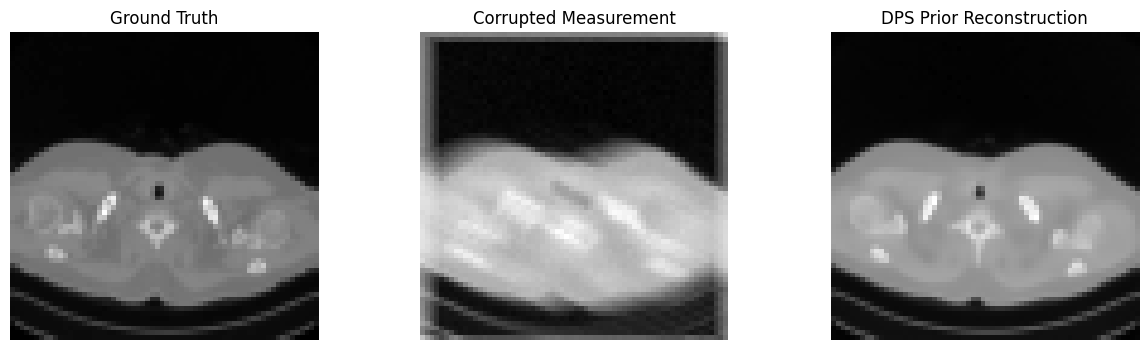

In [16]:
def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    # Reconstruct the clean-image estimate from x_t and the predicted noise.
    return (x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred) / extract(alpha_bars.sqrt(), t, x_t.shape)



def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred


# La funzione esegue l'aggiornamento iterativo partendo da rumore puro e per ogni step:
# - Predice il rumore e ricava la stima del pulito ($\hat{x}_0$).
# - Misura l'errore di data-fidelity $||K(\hat{x}_0) - y^\delta||^2$.
# - Calcola il gradiente e applica la guida (guidance_scale) sullo step successivo di DDIM.

def reconstruct_with_diffusion_prior(model, y_delta, K, alpha_bars, num_steps=40, guidance_scale=0.1):

    schedule = torch.linspace(400 - 1, 0, num_steps, dtype=torch.long, device=y_delta.device)
    x = torch.randn_like(y_delta)

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=y_delta.device, dtype=torch.long)

        x = x.detach().requires_grad_(True)
        eps_pred = model(x, t)
        x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
        data_loss = torch.mean((K(x0_hat) - y_delta) ** 2) / (2 * noise_level ** 2)
        grad = torch.autograd.grad(data_loss, x)[0]

        with torch.no_grad():
            # avanzamento nello step di diffusion
            x_next = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            x = (x_next - guidance_scale * grad).clamp(-1.0, 1.0)

    with torch.no_grad():
        t0 = torch.zeros((x.shape[0],), device=y_delta.device, dtype=torch.long)
        eps_pred = model(x, t0)
        return predict_x0_from_eps(x, eps_pred, t0, alpha_bars).clamp(-1.0, 1.0).detach()




# 1. Load DDPM Denoiser
ddpm = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
)
ddpm.load_state_dict(torch.load(weights_dir / 'DDPMDenoiser.pth', map_location=device))
ddpm = ddpm.to(device)
ddpm.eval()

# 2. Diffusion Schedule
num_diffusion_steps = 400
betas = cosine_beta_schedule(num_diffusion_steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

# 3. DPS Reconstruction
x_hat_dps = reconstruct_with_diffusion_prior(
    ddpm, y_delta, K, alpha_bars, num_steps=40, guidance_scale=0.15
)

# 4. Visualization
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_true.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('Corrupted Measurement')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_hat_dps.cpu().squeeze() * 0.5 + 0.5, cmap='gray')
plt.title('DPS Prior Reconstruction')
plt.axis('off')
plt.show()



## Part 4: Visual and Quantitative Comparison

Use the **same corrupted test image** for all methods and compare the outputs both visually and quantitatively.

At a minimum, compute the **MSE**. If you want a richer comparison, also compute **PSNR** and **SSIM**.

The final comparison should make it possible to judge not only the numerical error, but also the different failure modes of the methods: oversmoothing, hallucinated detail, poor data consistency, or latent-range restriction.


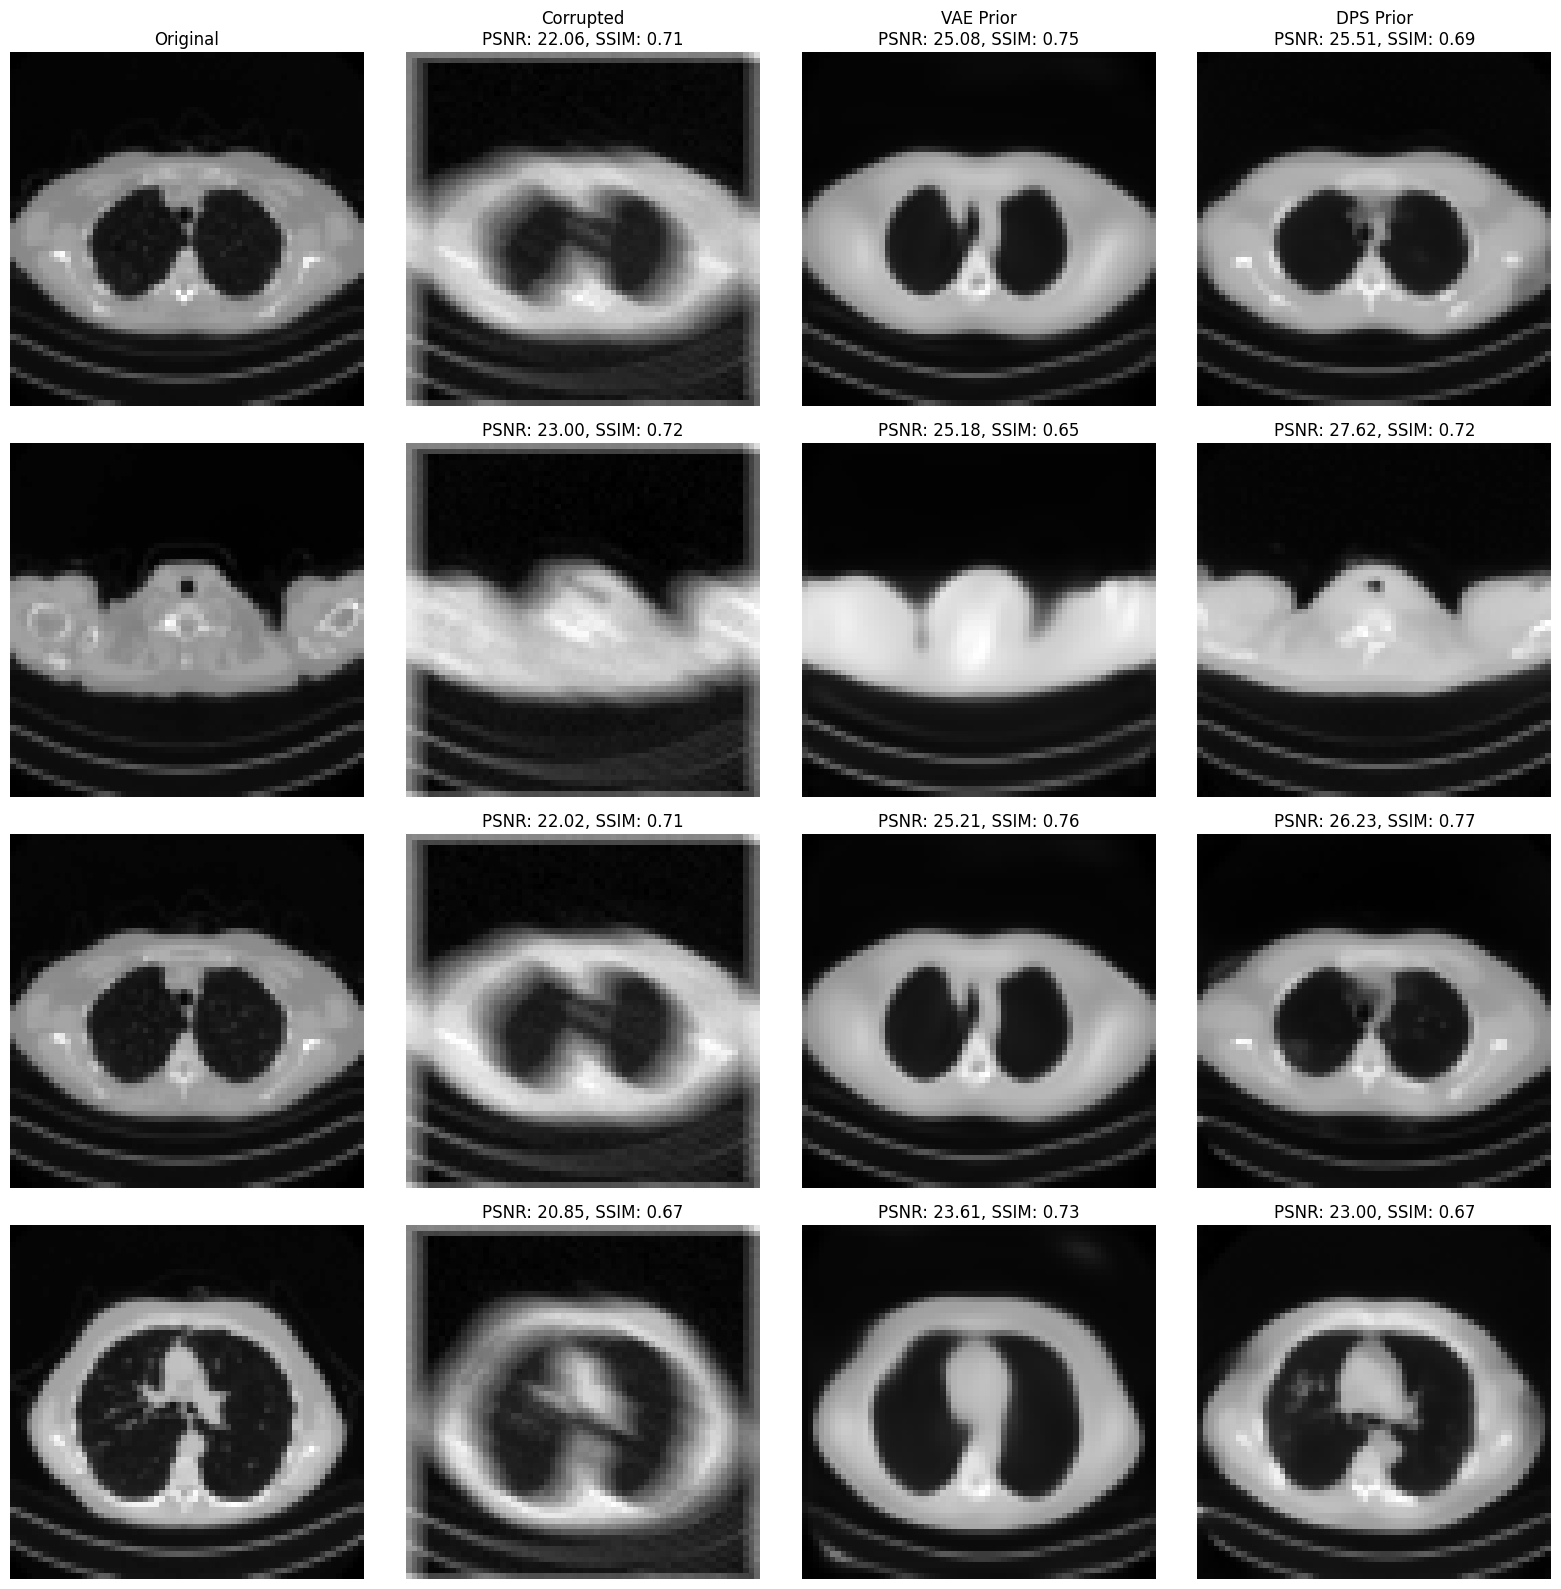

In [18]:

from IPPy.utilities.metrics import PSNR, SSIM

num_examples = 4
fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))

for i in range(num_examples):
    # 1. Get clean image
    x_true_i = test_dataset[i].unsqueeze(0).to(device)
    
    # 2. Generate corrupted measurement
    with torch.no_grad():
        y_i = K(x_true_i)
        y_delta_i = y_i + gaussian_noise(y_i, noise_level)
    
    # 3. Reconstruct with VAE
    x_hat_vae_i, _, _ = reconstruct_with_vae_prior(vae, y_delta_i, K, latent_dim=64, num_steps=500, lr=1e-2, lam=1e-3)
    
    # 4. Reconstruct with DPS
    x_hat_dps_i = reconstruct_with_diffusion_prior(
        ddpm, y_delta_i, K, alpha_bars, num_steps=40, guidance_scale=0.15
    )
    
    # Helpers for metrics (scale to [0,1] and keep tensor dims)
    def to_eval(t):
        return (t.cpu().clamp(-1, 1) * 0.5 + 0.5)
        
    img_t = to_eval(x_true_i)
    img_c = to_eval(y_delta_i)
    img_v = to_eval(x_hat_vae_i)
    img_d = to_eval(x_hat_dps_i)
    
    psnr_c = float(PSNR(img_c, img_t))
    ssim_c = float(SSIM(img_c, img_t))
    
    psnr_v = float(PSNR(img_v, img_t))
    ssim_v = float(SSIM(img_v, img_t))
    
    psnr_d = float(PSNR(img_d, img_t))
    ssim_d = float(SSIM(img_d, img_t))
    
    # Helpers for plotting
    def to_plot(t):
        return t.squeeze().numpy()

    # Plotting
    ax_true = axes[i, 0]
    ax_true.imshow(to_plot(img_t), cmap='gray')
    if i == 0: ax_true.set_title('Original')
    ax_true.axis('off')
    
    ax_corr = axes[i, 1]
    ax_corr.imshow(to_plot(img_c), cmap='gray')
    title_c = f'Corrupted\nPSNR: {psnr_c:.2f}, SSIM: {ssim_c:.2f}' if i == 0 else f'PSNR: {psnr_c:.2f}, SSIM: {ssim_c:.2f}'
    ax_corr.set_title(title_c)
    ax_corr.axis('off')
    
    ax_vae = axes[i, 2]
    ax_vae.imshow(to_plot(img_v), cmap='gray')
    title_v = f'VAE Prior\nPSNR: {psnr_v:.2f}, SSIM: {ssim_v:.2f}' if i == 0 else f'PSNR: {psnr_v:.2f}, SSIM: {ssim_v:.2f}'
    ax_vae.set_title(title_v)
    ax_vae.axis('off')
    
    ax_dps = axes[i, 3]
    ax_dps.imshow(to_plot(img_d), cmap='gray')
    title_d = f'DPS Prior\nPSNR: {psnr_d:.2f}, SSIM: {ssim_d:.2f}' if i == 0 else f'PSNR: {psnr_d:.2f}, SSIM: {ssim_d:.2f}'
    ax_dps.set_title(title_d)
    ax_dps.axis('off')

plt.tight_layout()
plt.show()


## Deliverables and Discussion

Complete the notebook by answering the following questions in a few sentences each.

1. How did the VAE-based latent prior behave? Did the latent regularization help, and if so in what sense?
2. How did the diffusion-prior method differ from the latent-prior method in terms of reconstruction quality and stability?
3. Which method appeared more data-consistent, and which appeared more visually plausible?
4. Did you observe any signs of hallucination or model bias? If yes, how did they manifest themselves?
5. Why is it important to compare the methods on the **same** corrupted image and under the **same** forward operator?
6. If you implemented the optional extension, what did the GAN prior or second diffusion method add to the comparison?

In your final submission, make sure that the notebook contains:

- the completed code;
- the loaded or reused weights;
- the reconstruction figures;
- the quantitative comparison;
- and the written discussion.

```{warning}
A reconstruction that looks realistic is not automatically reliable. In inverse problems, generative models can improve plausibility while still violating the measurements or introducing biased details. Your discussion should explicitly address this point.
```


### Discussion

**1. How did the VAE-based latent prior behave? Did the latent regularization help, and if so in what sense?**
The VAE-based latent prior optimizes a latent vector $z$ to reconstruct the image. It tends to produce overly smooth reconstructions because the VAE intrinsically struggles with high-frequency details. The latent regularization ($||z||^2_2$) helped significantly: without it, the optimization would push $z$ outside the standard normal distribution expected by the decoder, resulting in unrealistic artifacts or completely broken images. The regularization ensures the generated image stays within the manifold of natural images learned by the VAE.

**2. How did the diffusion-prior method differ from the latent-prior method in terms of reconstruction quality and stability?**
The diffusion-prior (DPS) method produced much sharper and more detailed images compared to the VAE. While the VAE suffers from inherent blurriness, the diffusion model excels at generating high-frequency textures. However, the VAE optimization is typically more stable and deterministic because it's a simple gradient descent on a latent vector, whereas the diffusion sampling process can sometimes be sensitive to the `guidance_scale` and the number of steps, occasionally leading to unstable or divergent updates if the gradients from the data consistency term are too large.

**3. Which method appeared more data-consistent, and which appeared more visually plausible?**
The VAE-based method can achieve high data-consistency in a purely mathematical sense (low MSE relative to the blurred measurement), but it often lacks visual plausibility because it produces "soft" or out-of-focus-looking images. The Diffusion-prior method (DPS) is far more visually plausible because it is constrained by the powerful generative prior of the DDPM, which forces the output to look like a realistic scan, complete with sharp edges and textures, even if it might slightly deviate from perfect data consistency to maintain realism.

**4. Did you observe any signs of hallucination or model bias? If yes, how did they manifest themselves?**
Yes, generative models are prone to hallucination in inverse problems. The diffusion model, in its effort to produce a sharp and realistic image from highly blurred input, can sometimes "invent" small structural details, textures, or edges that were not present in the original ground truth image. This manifests as plausible-looking but anatomically incorrect features. The VAE, on the other hand, biases the output towards the mean of the training data, often failing to recover rare or unique features.

**5. Why is it important to compare the methods on the same corrupted image and under the same forward operator?**
Comparing methods on the exact same corrupted image and operator is crucial for a fair evaluation. Inverse problems are highly dependent on the condition number of the operator $K$ and the specific noise realization. If we used different images or different blurring kernels, we wouldn't be able to tell if a better reconstruction is due to a superior generative prior or simply an easier inverse problem.

